In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# Load data
filepath = 'A01T.gdf'
raw = mne.io.read_raw_gdf(filepath, preload=True)
fs = raw.info['sfreq']


Extracting GDF parameters from A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


d:\Program Files\Python\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


In [ ]:
#Channel names
raw.ch_names

['EEG-Fz',
 'EEG-0',
 'EEG-1',
 'EEG-2',
 'EEG-3',
 'EEG-4',
 'EEG-5',
 'EEG-C3',
 'EEG-6',
 'EEG-Cz',
 'EEG-7',
 'EEG-C4',
 'EEG-8',
 'EEG-9',
 'EEG-10',
 'EEG-11',
 'EEG-12',
 'EEG-13',
 'EEG-14',
 'EEG-Pz',
 'EEG-15',
 'EEG-16',
 'EOG-left',
 'EOG-central',
 'EOG-right']

Using matplotlib as 2D backend.


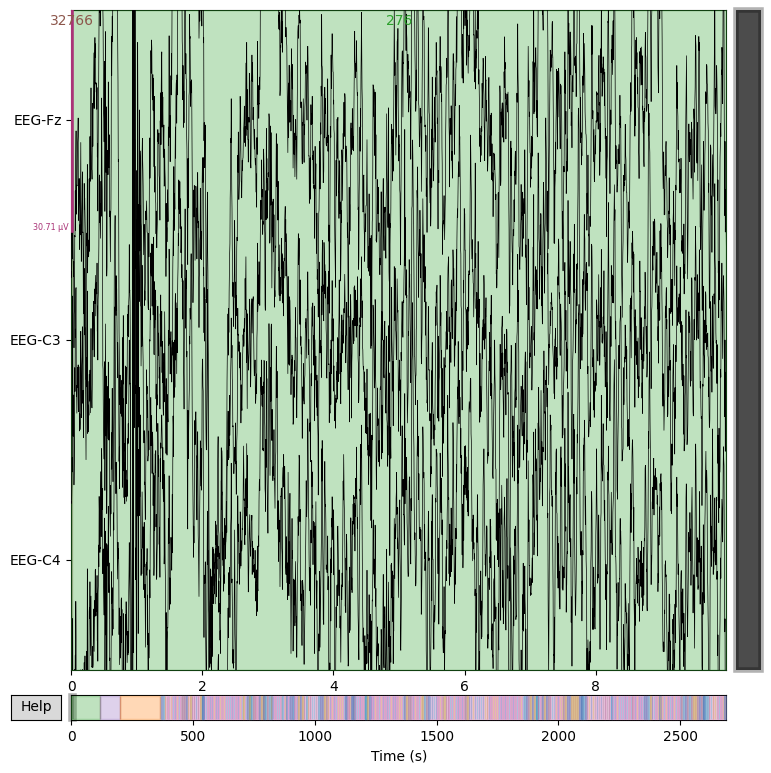

In [5]:
# Plot specific channels (C3, Cz, C4 - motor cortex)
channels = ['EEG-Fz', 'EEG-C3', 'EEG-C4']
raw.plot(duration=10, n_channels=3, scalings='auto', picks=channels)
plt.show()


In [49]:
# Extract data from 2 specific channels (For example C3 & Fz)
c3_index = raw.ch_names.index('EEG-C3')
c3_data = raw.get_data()[c3_index, :]

fz_index = raw.ch_names.index('EEG-Fz')
fz_data = raw.get_data()[fz_index, :]

In [14]:
c3_index

7

In [11]:
c3_data

array([-2.25097656e-05, -2.27539062e-05, -2.04101562e-05, ...,
        1.19628906e-05,  4.34570312e-06,  4.83398437e-06], shape=(672528,))

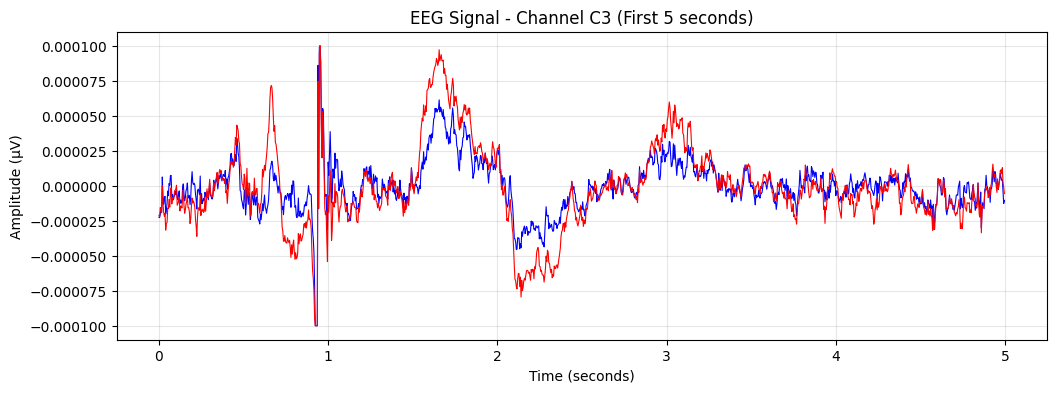

In [36]:
# Plot first 5 seconds of C3 & Fz to compare
time = np.arange(5 * fs) / fs
plt.figure(figsize=(12, 4))
plt.plot(time, c3_data[:1250], linewidth=0.8, color='blue')
plt.plot(time, fz_data[:1250], linewidth=0.8, color='red')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (µV)')
plt.title('EEG Signal - Channel C3 (First 5 seconds)')
plt.grid(True, alpha=0.3)
plt.show()



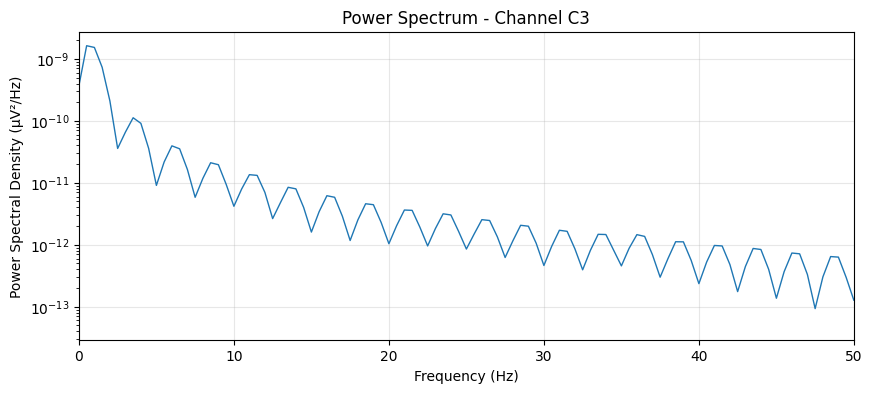

In [50]:
# Power Spectral Density of C3
from scipy import signal
frequencies, psd = signal.welch(c3_data, fs, nperseg=fs*2)

plt.figure(figsize=(10, 4))
plt.semilogy(frequencies, psd, linewidth=1)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (µV²/Hz)')
plt.title('Power Spectrum - Channel C3')
plt.grid(True, alpha=0.3)
plt.xlim(0, 50)
plt.show()


In [ ]:
# Check signal statistics/ Print statistics with proper scaling
c3_data = raw.get_data()[c3_index, :] * 1e6  # Convert to microvolts (µV)

print(f"Channel C3 statistics:")
print(f"  Mean: {c3_data.mean():.2f} µV")
print(f"  Std: {c3_data.std():.2f} µV")
print(f"  Min: {c3_data.min():.2f} µV")
print(f"  Max: {c3_data.max():.2f} µV")

Channel C3 statistics:
  Mean: -1.56 µV
  Std: 56.26 µV
  Min: -1600.00 µV
  Max: 99.95 µV
